# **Decision Tree Algorithm**

- A **decision tree** is a flowchart-like structure used in machine learning and decision analysis to model decisions and their possible consequences.

- It is intuitive, easy to visualize, and powerful for both **classification** and **regression** tasks.

**Core Components:**

- **Root Node**: Represents the entire dataset and the first decision point.

- **Internal Nodes**: Each node splits the data based on a feature.

- **Branches**: Paths that represent outcomes of a decision or test.

- **Leaf Nodes**: Final output or prediction (class label or value).

**How It Works:**

1. Start at the root node.

2. Choose the best feature to split the data (using metrics like **Gini Impurity** or **Entropy**).

3. Recursively split the data at each node until:

   - All samples belong to one class (for classification).

   - No further gain is possible.

   - A stopping criterion is met (like max depth or min samples per leaf).

# **Example:**

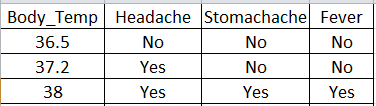

# **Step-by-Step Tree Construction:**

- Start with Body_Temp as a numerical feature:

- Try splitting at 37.6 (average of 37.2 and 38.0)

- Samples ≤ 37.6: Rows 1 and 2 → Fever = No

- Samples > 37.6: Row 3 → Fever = Yes

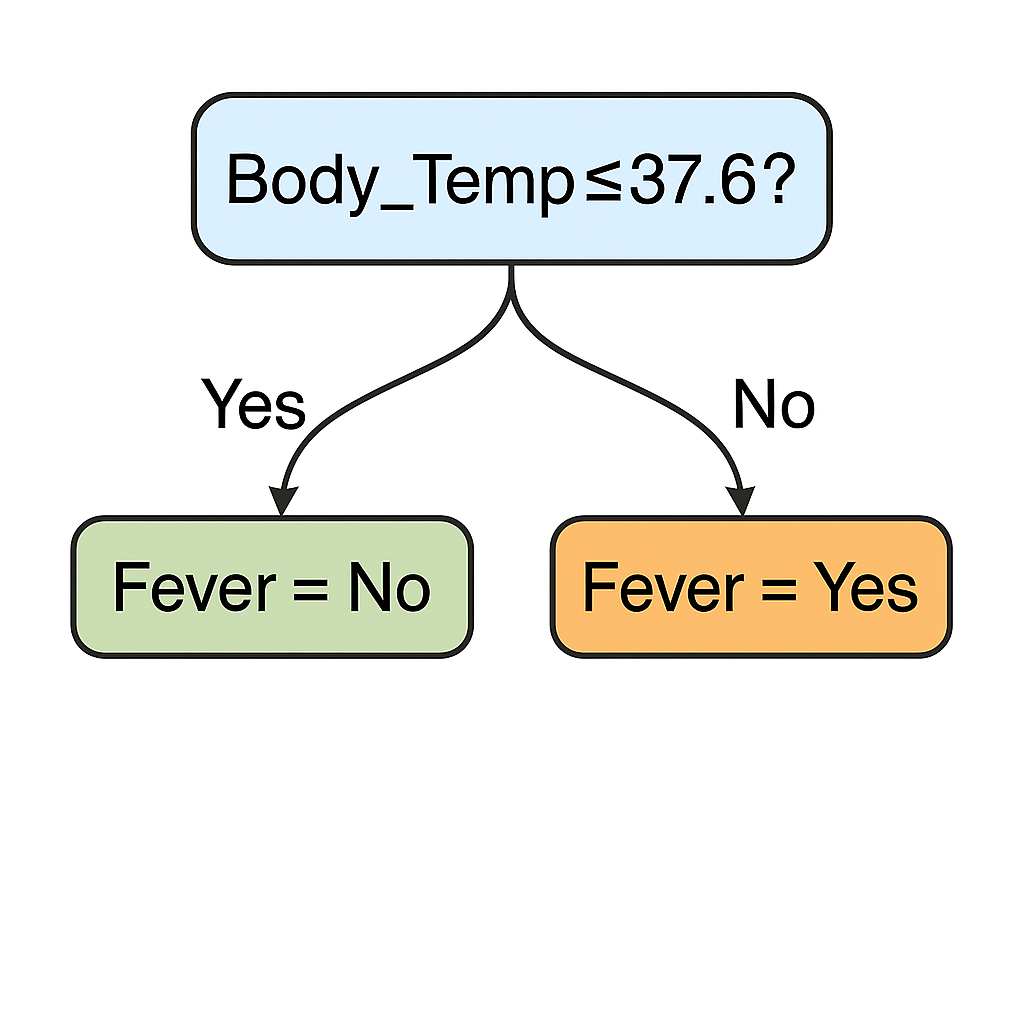

# **Example - 2:**

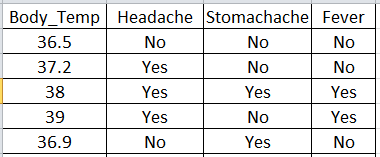

- **First split on Headache:*** If no headache, all Fever values are No (Rows 1 and 5).

- For **Headache = Yes**, we observe:

    - Row 2: Temp = 37.2 → Fever = No

    - Rows 3 & 4: Temp ≥ 38.0 → Fever = Yes

- So we split based on **Body_Temp > 37.5** to separate these correctly.


# **Algorithms Commonly Used to Create Decision Trees:**



- **ID3 (Iterative Dichotomiser 3)**  
  - Uses entropy and information gain  
  - Splits on feature with highest information gain

- **C4.5**  
  - Extension of ID3; supports continuous and missing data  
  - Uses gain ratio to select features

- **CART (Classification and Regression Trees)**  
  - Can perform classification and regression  
  - Uses Gini impurity (for classification) and variance reduction (for regression)

- **CHAID (Chi-squared Automatic Interaction Detector)**  
  - Based on chi-square tests for statistical significance  
  - Often used for categorical predictors

- **Random Forest**  
  - Ensemble of multiple decision trees  
  - Uses bootstrap aggregation (bagging) and random feature selection

- **XGBoost (Extreme Gradient Boosting)**  
  - Boosted decision trees for high performance  
  - Builds trees sequentially to minimize errors

- **LightGBM (Light Gradient Boosting Machine)**  
  - Optimized for speed and memory usage  
  - Good for large-scale data and high dimensionality

- **AdaBoost (Adaptive Boosting)**  
  - Converts weak learners into strong ones  
  - Focuses more on incorrectly classified samples in each iteration

# **Impurity**

- In decision trees, **impurity** is a measure of how mixed or disordered the class labels are within a node.

- It helps the algorithm decide where to split the data to create more homogeneous groups—ultimately improving prediction accuracy.

- Impurity quantifies the **degree of heterogeneity** in a node. A node is:

    - **Pure** if all samples belong to the same class.
    
    - **Impure** if samples are spread across multiple classes.


- The goal of a decision tree is to **reduce impurity** with each split, creating branches that lead to more confident predictions.

# **Impurity Measures**

**1. Gini Impurity**

- Measures the probability of misclassifying a randomly chosen sample.

- Formula:  
  $$ Gini = 1 - \sum_{i=1}^{k} p_i^2 $$

- Where ( $p_i$ ) is the proportion of class ( i ) in the node.

- **Range**: 0 (pure) to 0.5 (maximum impurity for binary classification)

**2. Entropy**

- Measures the amount of uncertainty or disorder.

- Formula:

  $$ Entropy = - \sum_{i=1}^{k} p_i \log_2(p_i) $$

- **Range**: 0 (pure) to 1 (maximum uncertainty)

**3. Classification Error**

- Measures the fraction of samples not belonging to the majority class.

- Formula:  

  $$ Error = 1 - \max(p_i) $$
  
- Less commonly used due to lower sensitivity to changes in class distribution.

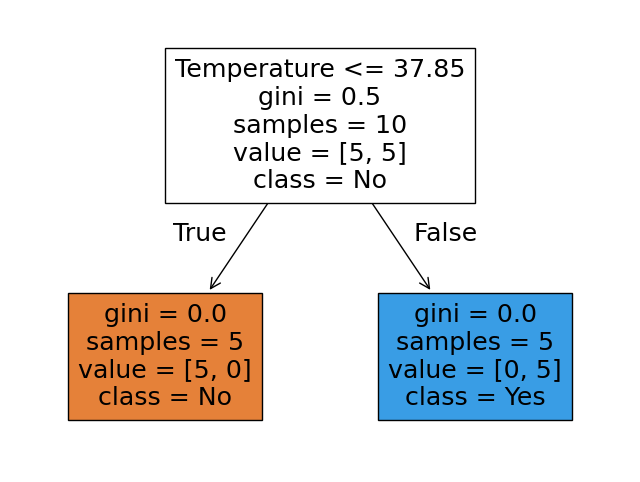

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Dataset
df = pd.DataFrame({
    'Temperature': [38.5, 36.7, 39.2, 37.0, 39.5, 36.8, 38.9, 37.2, 39.0, 36.5],
    'Headache': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No'],
    'Stomachache': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No'],
    'Fever': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No']
})

# Let us Encode categorical features
le = LabelEncoder()
for col in ['Headache', 'Stomachache', 'Fever']:
    df[col] = le.fit_transform(df[col])

# Let us Train CART model
X = df[['Temperature', 'Headache', 'Stomachache']]
y = df['Fever']
model = DecisionTreeClassifier(criterion='gini', max_depth=2)
model.fit(X, y)

# Let us Visualize Tree
plt.figure(figsize=(8,6))
plot_tree(model,
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True)
plt.show()

# **Example - 2**

In [ ]:
import pandas as pd

data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain',
                'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast',
                'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild',
                    'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High',
                 'Normal', 'High'],
    'Windy': [False, True, False, False, False, True,
              True, False, False, False, True, True,
              False, True],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
                   'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes',
                   'Yes', 'No']
}

df = pd.DataFrame(data)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['Outlook', 'Temperature', 'Humidity', 'Windy', 'PlayTennis']:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']
model = DecisionTreeClassifier(criterion='gini',
                               max_depth=3,
                               random_state=42)
model.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

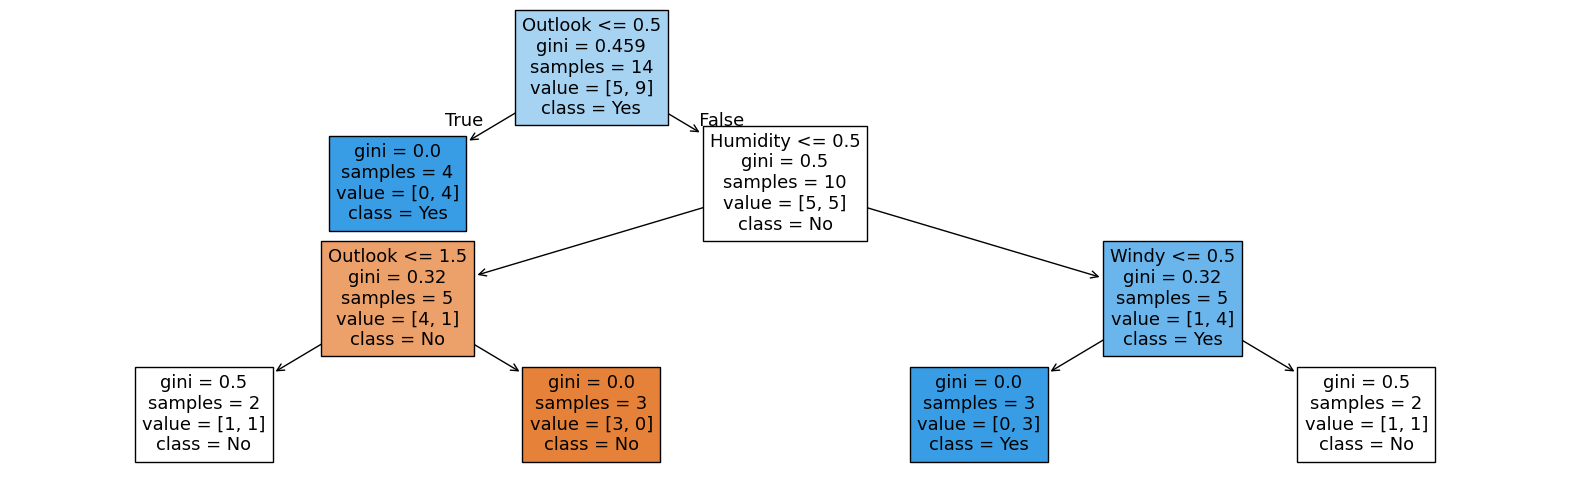

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
plot_tree(model,
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True)
plt.show()

# **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeCLassifier
dt=DecisionTreeCLassifier()
dt.fit(X_train_trans,y_train)

In [ ]:
y_pred=dt.predict(X_test_trans)

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

In [1]:
import pandas as pd
import numpy as np

In [ ]:
d = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain',
                'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast',
                'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild',
                    'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High',
                 'Normal', 'High'],
    'Windy': [False, True, False, False, False, True,
              True, False, False, False, True, True,
              False, True],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
                   'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes',
                   'Yes', 'No']
}

In [1]:
import pandas as pd

# Data as dictionary
data = {
    "SquareFeet": [800, 1200, 1500, 600, 1800, 1000, 2000, 1300, 1700, 900],
    "Bedrooms":   [2, 3, 3, 1, 4, 2, 4, 3, 3, 2],
    "Parking":    [0, 1, 1, 0, 2, 1, 2, 0, 2, 1],
    "Price":      [35, 55, 65, 25, 90, 45, 100, 58, 85, 40]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display DataFrame
df


,SquareFeet,Bedrooms,Parking,Price
0,800,2,0,35
1,1200,3,1,55
2,1500,3,1,65
3,600,1,0,25
4,1800,4,2,90
5,1000,2,1,45
6,2000,4,2,100
7,1300,3,0,58
8,1700,3,2,85
9,900,2,1,40


In [3]:
df['Price'].sum()/len(df)

59.8

In [5]:
y_true = df['SquareFeet']
y_pred = df['Price'] # Selecting only this single column

# 2. Calculate MSE
mse = np.mean((y_true - y_pred) ** 2)
mse

1662261.4

In [6]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true,y_pred)

1662261.4

In [10]:
y_true = [600, 800, 900, 1000]
y_pred = [25, 35, 40, 45]

mse = sum((y_true[i] - y_pred[i])**2 for i in range(len(y_true))) / len(y_true)
mse


641868.75

In [11]:
import numpy as np
import pandas as pd

def calculate_column_mse(y_true, y_pred):
 
    mse = np.mean((actual - predicted) ** 2)
    
    return mse

# --- Example Usage with a Dataframe ---

# 1. Create a dummy table (DataFrame)
data = {
    'actual_values':[600, 800, 900, 1000],
    'predicted_column':[25, 35, 40, 45]
}
df = pd.DataFrame(data)

# 2. Extract only the columns you want to calculate
true_col = df['actual_values']
pred_col = df['predicted_column']

# 3. Run the function
result = calculate_column_mse(true_col, pred_col)

print(f"Calculated MSE: {result}")


NameError: name 'actual' is not defined

In [16]:
y_true = [800,1200,600,1000,1300,900]
y_pred = [35,55,25,45,58,40]
mean_squared_error(y_pred,y_true)

903510.6666666666

In [12]:
35+55+25+45+58+40

258

In [13]:
258/6

43.0

In [14]:
mean_squared_error(y_true,y_pred)

InvalidParameterError: The 'y_pred' parameter of mean_squared_error must be an array-like. Got 43.0 instead.

In [23]:
y = df["Bedrooms"]

# Example predicted values (replace with your model predictions)
y_pred = [55,65,58,85]
n = len(y_pred)
mse = sum((y[i] - y_pred[i])**2 for i in range(n)) /n
mse

4183.5

In [24]:
55+65+45+40

205

In [25]:
205/4

51.25

In [31]:
d = [55,65,45,40]
mse = 0
for i in d:
    mse += (i - 51.25) **2
mse/len(d)

92.1875

In [27]:
35+25+90+100+58+85

393

In [28]:
393/6

65.5

In [8]:
d = [65,90,100,58,85]
mean = sum(d)/len(d)
mse = 0
for i in d:
    mse +=  (i - mean) **2
mse/len(d)

246.64000000000001

In [9]:
sum(d)/len(d)

79.6